In [22]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy, pickle
from tqdm import tqdm
from scipy import ndimage

In [32]:
# Trajectory grid bounds and map resolution.
# 1000 points per trajectory / 32x32 bins ~= 1 raw sample per bin before smoothing —
# fine enough to resolve field structure without every bin being empty.
BOUNDS = (0.0, 1.0)
N_BINS = 40
SIGMA = 0.5     # Gaussian smoothing bandwidth, in bins
EPS = 1e-12

SKIP_TIMESTEPS = 50


SI_THRESHOLD = 0
SPARSITY_THRESHOLD = 0


#### Data extraction

In [33]:
def occupancy_map_func(pos, reso=40, win_len=9, debug=False):
    """
    Calculate occupancy map.

    Parameters
    ----------
    pos : (N,2)
        x,y positions

    reso : int
        Half the number of bins (total bins = 2*reso)

    debug : bool
        If True, print diagnostics and plot intermediate results.
    """

    if debug:
        print("=" * 50)
        print("INPUT")
        print("=" * 50)
        print("Position shape:", pos.shape)
        print(f"x range: [{pos[:,0].min():.3f}, {pos[:,0].max():.3f}]")
        print(f"y range: [{pos[:,1].min():.3f}, {pos[:,1].max():.3f}]")
        print()

    # ---------------------------------------------------------
    # Raw occupancy histogram
    # ---------------------------------------------------------

    H1, xedges, yedges = np.histogram2d(
        pos[:, 0],
        pos[:, 1],
        bins=reso * 2,
    )

    if debug:
        print("=" * 50)
        print("RAW HISTOGRAM")
        print("=" * 50)
        print("Shape:", H1.shape)
        print("Total visits:", H1.sum())
        print("Maximum bin:", H1.max())
        print("Occupied bins:", np.count_nonzero(H1))

        plt.figure(figsize=(5,5))
        plt.imshow(H1.T, origin="lower")
        plt.title("Raw Occupancy Histogram")
        plt.colorbar()
        plt.show()

    # ---------------------------------------------------------
    # Gaussian
    # ---------------------------------------------------------

    gaussian = matlab_style_gauss2D((win_len, win_len), sigma=3)

    if debug:
        print("=" * 50)
        print("GAUSSIAN")
        print("=" * 50)
        print("Shape:", gaussian.shape)
        print("Sum:", gaussian.sum())

        plt.figure(figsize=(4,4))
        plt.imshow(gaussian)
        plt.title("Gaussian Kernel")
        plt.colorbar()
        plt.show()

    # ---------------------------------------------------------
    # Convolution
    # ---------------------------------------------------------

    conv = scipy.signal.convolve2d(
        gaussian,
        H1,
    )

    if debug:
        print("=" * 50)
        print("AFTER CONVOLUTION")
        print("=" * 50)
        print("Shape:", conv.shape)

        plt.figure(figsize=(5,5))
        plt.imshow(conv.T, origin="lower")
        plt.title("Smoothed Occupancy")
        plt.colorbar()
        plt.show()

    # ---------------------------------------------------------
    # Crop
    # ---------------------------------------------------------

    pos_prob = conv[
        int(win_len/2):-int(win_len/2),
        int(win_len/2):-int(win_len/2)
    ]

    if debug:
        print("=" * 50)
        print("AFTER CROPPING")
        print("=" * 50)
        print("Shape:", pos_prob.shape)

        plt.figure(figsize=(5,5))
        plt.imshow(pos_prob.T, origin="lower")
        plt.title("After Cropping")
        plt.colorbar()
        plt.show()

    # ---------------------------------------------------------
    # Normalize
    # ---------------------------------------------------------

    total = np.nansum(pos_prob)

    if debug:
        print("Sum before normalization:", total)

    pos_prob = pos_prob / total

    if debug:
        print("Sum after normalization:", np.nansum(pos_prob))

    # ---------------------------------------------------------
    # Mask empty bins
    # ---------------------------------------------------------

    pos_prob[pos_prob == 0] = np.nan

    if debug:
        print("=" * 50)
        print("FINAL OCCUPANCY MAP")
        print("=" * 50)
        print("NaNs:", np.isnan(pos_prob).sum())
        print("Finite bins:", np.isfinite(pos_prob).sum())

        plt.figure(figsize=(6,6))
        plt.imshow(pos_prob.T, origin="lower")
        plt.title("Final Occupancy Map")
        plt.colorbar()
        plt.show()

    return pos_prob

In [46]:
def firing_rate_map_place_cells(
    resp_neurons,
    positions,
    occupancy_map,
    thresh_param=0.0,
    title="",
    ticks_colbar=None,
    res_param=40,
    sub_plot=False,
    debug=False,
):
    """
    Compute firing rate map with optional debugging.
    """

    res = res_param

    mean_resp = np.mean(resp_neurons)
    std_resp = np.std(resp_neurons)
    thresh = mean_resp + thresh_param * std_resp

    firr = np.nonzero(resp_neurons > thresh)

    firposgrid = positions[firr[0], :2]
    firingvalue = resp_neurons[firr]

    if debug:
        print("="*60)
        print("Neuron statistics")
        print("="*60)
        print(f"Mean activation      : {mean_resp:.5f}")
        print(f"Std activation       : {std_resp:.5f}")
        print(f"Threshold            : {thresh:.5f}")
        print(f"Total samples        : {len(resp_neurons)}")
        print(f"Samples above thresh : {len(firingvalue)}")
        print(f"Percentage           : {100*len(firingvalue)/len(resp_neurons):.2f}%")
        print()

    # ----------------------------------------------------
    # Plot spike locations
    # ----------------------------------------------------

    if debug:

        plt.figure(figsize=(6,6))

        plt.scatter(
            positions[:,0],
            positions[:,1],
            s=1,
            alpha=0.15,
            label="trajectory"
        )

        plt.scatter(
            firposgrid[:,0],
            firposgrid[:,1],
            s=6,
            c="red",
            label="selected"
        )

        plt.legend()
        plt.axis("equal")
        plt.title("Thresholded activity")
        plt.show()

    # ----------------------------------------------------

    x = np.arange(-1, 1, 1/res)
    y = np.arange(-1, 1, 1/res)

    fx, fy = np.meshgrid(x, y)

    firingmap = np.zeros(fx.shape)

    visited = {}

    for ii in range(len(firposgrid)):

        q1 = np.argmin(np.abs(firposgrid[ii,0] - fx[1,:]))
        q2 = np.argmin(np.abs(firposgrid[ii,1] - fy[:,1]))

        if debug and ii < 15:

            print(
                f"{ii:3d}: "
                f"({firposgrid[ii,0]: .3f}, {firposgrid[ii,1]: .3f}) "
                f"-> bin ({q1:2d},{q2:2d}) "
                f"value={firingvalue[ii]:.4f}"
            )

        visited[(q1,q2)] = visited.get((q1,q2),0) + 1

        firingmap[q1,q2] = max(
            firingvalue[ii],
            firingmap[q1,q2]
        )

    if debug:

        print()
        print("="*60)
        print("Bin statistics")
        print("="*60)
        print("Unique bins:", len(visited))
        print("Total spikes:", len(firingvalue))
        print("Maximum spikes in one bin:", max(visited.values()))

        plt.figure(figsize=(6,6))
        plt.imshow(firingmap.T, origin="lower")
        plt.colorbar()
        plt.title("Before occupancy normalization")
        plt.show()

    print("Occupancy statistics")
    print("--------------------")
    print("min:", np.nanmin(occupancy_map))
    print("max:", np.nanmax(occupancy_map))
    print("mean:", np.nanmean(occupancy_map))

    print()

    print("Firing map statistics BEFORE division")
    print(np.nanmin(firingmap))
    print(np.nanmax(firingmap))
    
    occupancy = occupancy_map + epsilon

    firingmap = firingmap / occupancy

    print()

    print("After division")
    print(np.nanmin(firingmap))
    print(np.nanmax(firingmap))

    gaussian = matlab_style_gauss2D((9,9),3)

    spikes_smooth = scipy.signal.convolve2d(
        gaussian,
        firingmap
    )

    rotated_img = ndimage.rotate(spikes_smooth,90)

    win_len = 9

    rotated_img = rotated_img[
        int(win_len/2):-int(win_len/2),
        int(win_len/2):-int(win_len/2)
    ]

    if not sub_plot:

        plt.imshow(rotated_img,cmap="jet")
        plt.colorbar()
        plt.title(title)
        plt.show()

    return rotated_img

In [47]:
def matlab_style_gauss2D(shape,sigma):
    """
    2D gaussian mask - should give the same result as MATLAB's
    fspecial('gaussian',[shape],[sigma])
    """
    m,n = [(ss-1.)/2. for ss in shape]
    y,x = np.ogrid[-m:m+1,-n:n+1]
    h = np.exp( -(x*x + y*y) / (2.*sigma*sigma) )
    h[ h < np.finfo(h.dtype).eps*h.max() ] = 0
    sumh = h.sum()
    if sumh != 0:
      h /= sumh
    return h

In [48]:
def get_input_data(
    pkl_path,
    layer_name,
    representation="magnitude",
):

    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    positions = []
    activations = []

    for key in sorted(data.keys()):

        sample = data[key]

        # choose GT or prediction
        positions.append(np.squeeze(sample["predicted_position"]))
        # or:
        # positions.append(np.squeeze(sample["true_position"]))

        if representation == "real":
            act = sample[f"{layer_name}_real"]

        elif representation == "imag":
            act = sample[f"{layer_name}_imag"]

        elif representation == "phase":
            act = sample[f"{layer_name}_phase"]

        elif representation == "magnitude":

            if layer_name in sample:
                act = np.abs(sample[layer_name])

            else:
                act = np.sqrt(
                    sample[f"{layer_name}_real"]**2 +
                    sample[f"{layer_name}_imag"]**2
                )

        activations.append(np.squeeze(act))

    positions = np.asarray(positions)
    activations = np.asarray(activations)

    if SKIP_TIMESTEPS > 0:
        positions = positions[:, SKIP_TIMESTEPS:, :]
        activations = activations[:, SKIP_TIMESTEPS:, :]

    return positions, activations

### Identifying place cells

#### Download DONN activations & extract corresponding positions

In [49]:
# Get input data
pkl_path = "/Users/ais/Desktop/2026_Summer/2d_hippocampal_cells/10-traj-results-training.pkl"

layer_name = "z3"
representation = "phase"

positions, activations = get_input_data(
    pkl_path,
    layer_name="z3",
    representation="magnitude",
)

positions = positions.reshape(-1, 2)
activations = activations.reshape(-1, activations.shape[-1])


print("Positions    :", positions.shape)
print("Activations  :", activations.shape)





Positions    : (4500, 2)
Activations  : (4500, 100)


INPUT
Position shape: (4500, 2)
x range: [0.068, 0.951]
y range: [0.082, 0.930]

RAW HISTOGRAM
Shape: (80, 80)
Total visits: 4500.0
Maximum bin: 20.0
Occupied bins: 1492


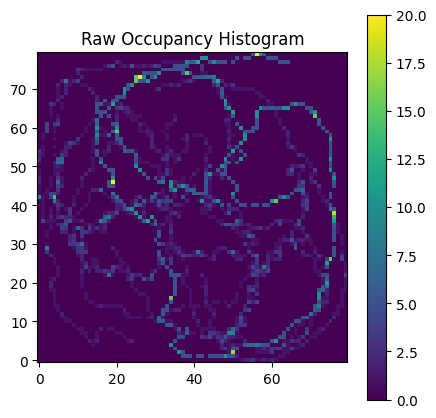

GAUSSIAN
Shape: (9, 9)
Sum: 0.9999999999999999


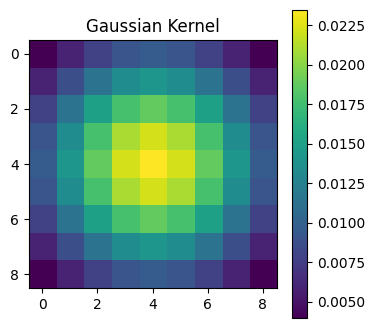

AFTER CONVOLUTION
Shape: (88, 88)


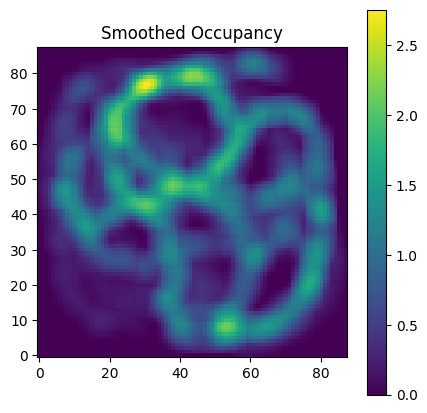

AFTER CROPPING
Shape: (80, 80)


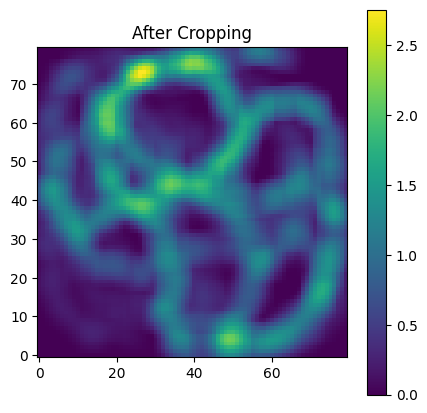

Sum before normalization: 4376.587561004888
Sum after normalization: 0.9999999999999998
FINAL OCCUPANCY MAP
NaNs: 315
Finite bins: 6085


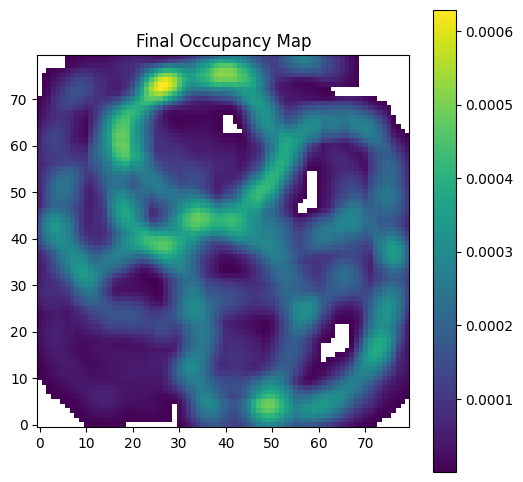

In [50]:
occupancy = occupancy_map_func(
    positions,
    reso=40,
    debug=True,
)

Neuron statistics
Mean activation      : 0.96972
Std activation       : 0.23234
Threshold            : 1.31822
Total samples        : 4500
Samples above thresh : 255
Percentage           : 5.67%



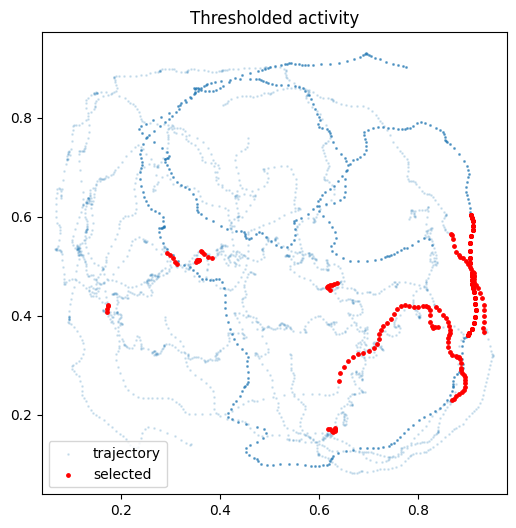

  0: ( 0.906,  0.605) -> bin (76,64) value=1.3803
  1: ( 0.909,  0.598) -> bin (76,64) value=1.4405
  2: ( 0.910,  0.591) -> bin (76,64) value=1.4598
  3: ( 0.911,  0.582) -> bin (76,63) value=1.4424
  4: ( 0.910,  0.573) -> bin (76,63) value=1.4221
  5: ( 0.908,  0.561) -> bin (76,62) value=1.3998
  6: ( 0.905,  0.547) -> bin (76,62) value=1.3770
  7: ( 0.904,  0.531) -> bin (76,61) value=1.3554
  8: ( 0.904,  0.516) -> bin (76,61) value=1.3361
  9: ( 0.905,  0.506) -> bin (76,60) value=1.3201
 10: ( 0.909,  0.486) -> bin (76,59) value=1.3380
 11: ( 0.909,  0.485) -> bin (76,59) value=1.3686
 12: ( 0.908,  0.480) -> bin (76,59) value=1.3938
 13: ( 0.908,  0.473) -> bin (76,59) value=1.4092
 14: ( 0.909,  0.465) -> bin (76,59) value=1.4153

Bin statistics
Unique bins: 52
Total spikes: 255
Maximum spikes in one bin: 26


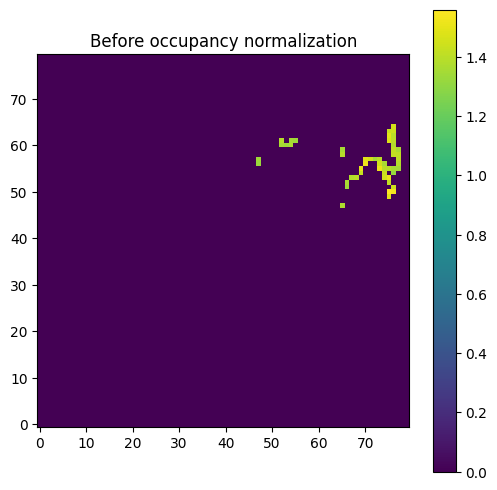

Occupancy statistics
--------------------
min: -1.2611760042018828e-21
max: 0.000628551832501467
mean: 0.00015625

Firing map statistics BEFORE division
0.0
1.560117244720459

After division
0.0
65784.07767727104


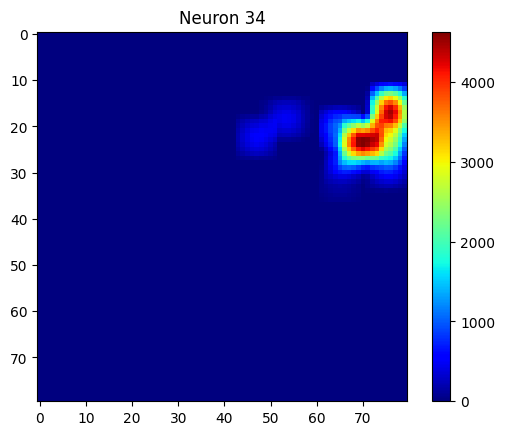

array([[-3.47397964e-50,  4.34574855e-50, -6.46915441e-49, ...,
        -3.66069708e-21, -1.01443230e-20,  1.33747337e-20],
       [-2.98608824e-49, -1.20302811e-48, -2.53338582e-48, ...,
        -9.15200999e-21, -4.84159347e-20, -5.35497331e-20],
       [-1.76699145e-49, -2.87545213e-48, -2.13782463e-47, ...,
         4.57008947e-19,  6.17182849e-20, -1.34600849e-19],
       ...,
       [-6.63430143e-69,  7.44546715e-68,  2.65196538e-67, ...,
        -7.19716759e-39, -5.17514540e-39, -3.18123565e-39],
       [-6.18771516e-69, -6.63461646e-69,  7.44547502e-68, ...,
         1.79013026e-39,  1.28459525e-39,  7.47915358e-40],
       [-1.07039173e-69, -1.08241441e-68,  1.19114143e-68, ...,
        -5.02886998e-40, -3.70755633e-40, -2.29425234e-40]])

In [51]:
neuron = 34

firing_rate_map_place_cells(
    resp_neurons=activations[:, neuron],
    positions=positions,
    occupancy_map=occupancy_map.copy(),   # avoid modifying original
    thresh_param=1.5,
    debug=True,
    title=f"Neuron {neuron}",
)